# KIND model training

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

curr_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(curr_dir, '..', '..'))
sys.path.append(root_dir)

data_dir = '../../data/duffing'
model_dir = '../../models/duffing'

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import example_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', data_dir,
        '--file_name', 'duffing',
        '--data_nsample_baseline', '619',
        '--data_nsample_nom', '253',
        '--data_nsample_exc', '460',
        '--obs_ndim', '2',
        '--act_ndim', '1',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--back_nsample', '64',
        '--fore_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', model_dir,

        '--rez_nsample_nom', '32',
        '--rez_nsample_exc', '16',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = torch.tensor([1.0, 0.0])

In [3]:
# --! create model, dataset and training

model = kind.model(args)
dataset = example_duffing.dataset(args, setpoint, load_normalized=True, extract_windows=True)
training = kind.training(model)

torch.Size([1, 619, 3])


## Train nominal model

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.187894, valid=1.207430, test=1.159412
	validation loss decreased (inf -> 1.207430), saving model ...
	epoch 2 losses: train=1.146622, valid=1.170403, test=1.111789
	validation loss decreased (1.207430 -> 1.170403), saving model ...
	epoch 3 losses: train=1.100607, valid=1.123764, test=1.050038
	validation loss decreased (1.170403 -> 1.123764), saving model ...
	epoch 4 losses: train=1.016384, valid=1.067498, test=0.968931
	validation loss decreased (1.123764 -> 1.067498), saving model ...
	epoch 5 losses: train=0.938632, valid=1.008599, test=0.865692
	validation loss decreased (1.067498 -> 1.008599), saving model ...
	epoch 6 losses: train=0.880064, valid=0.969314, test=0.759650
	validation loss decreased (1.008599 -> 0.969314), saving model ...
	epoch 7 losses: train=0.870923, valid=0.962993, test=0.698524
	validation loss decreased (0.969314 -> 0.962993), saving model ...
	epoch 8 losses: train=0.808974, valid=0.935731, test=0.67

In [5]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

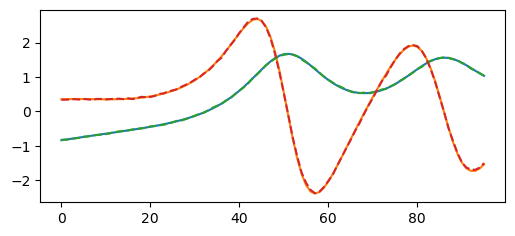

In [6]:
jdata = 15

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break


## Train nominal model's uncertainty

In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.945906, valid=0.818661, test=1.099989
	validation loss decreased (inf -> 0.818661), saving model ...
	epoch 2 losses: train=0.929688, valid=0.595425, test=0.833946
	validation loss decreased (0.818661 -> 0.595425), saving model ...
	epoch 3 losses: train=0.696580, valid=0.523839, test=0.795831
	validation loss decreased (0.595425 -> 0.523839), saving model ...
	epoch 4 losses: train=0.645370, valid=0.410176, test=0.651117
	validation loss decreased (0.523839 -> 0.410176), saving model ...
	epoch 5 losses: train=0.609862, valid=0.393121, test=0.632017
	validation loss decreased (0.410176 -> 0.393121), saving model ...
	epoch 6 losses: train=0.573269, valid=0.386772, test=0.622808
	validation loss decreased (0.393121 -> 0.386772), saving model ...
	epoch 7 losses: train=0.550035, valid=0.369390, test=0.607456
	validation loss decreased (0.386772 -> 0.369390), saving model ...
	epoch 8 losses: train=0.550263, valid=0.361111, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

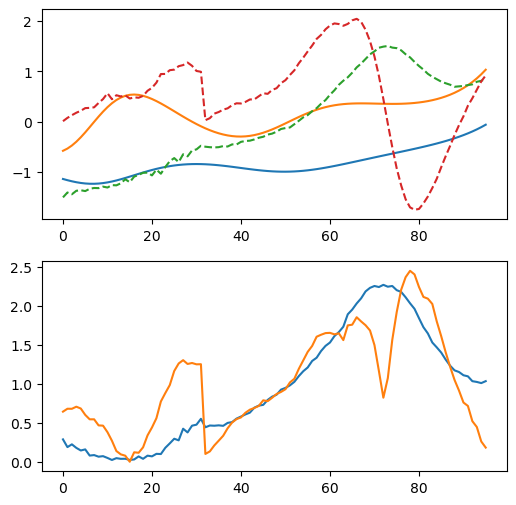

In [9]:
jdata = 5

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break


## Train excursion model

In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.898331, valid=0.865264, test=1.046465
	validation loss decreased (inf -> 0.865264), saving model ...
	epoch 2 losses: train=0.863193, valid=0.809631, test=0.988794
	validation loss decreased (0.865264 -> 0.809631), saving model ...
	epoch 3 losses: train=0.857614, valid=0.705703, test=0.874431
	validation loss decreased (0.809631 -> 0.705703), saving model ...
	epoch 4 losses: train=0.754666, valid=0.555972, test=0.720331
	validation loss decreased (0.705703 -> 0.555972), saving model ...
	epoch 5 losses: train=0.674669, valid=0.470309, test=0.634161
	validation loss decreased (0.555972 -> 0.470309), saving model ...
	epoch 6 losses: train=0.571201, valid=0.440425, test=0.603906
	validation loss decreased (0.470309 -> 0.440425), saving model ...
	epoch 7 losses: train=0.539492, valid=0.417829, test=0.570827
	validation loss decreased (0.440425 -> 0.417829), saving model ...
	epoch 8 losses: train=0.445832, valid=0.405967, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

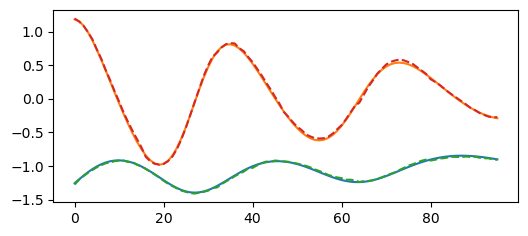

In [12]:
jdata = 7

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

## Train excursion model's uncertainty

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.308573, valid=0.313064, test=0.280856
	validation loss decreased (inf -> 0.313064), saving model ...
	epoch 2 losses: train=0.325131, valid=0.311340, test=0.276730
	validation loss decreased (0.313064 -> 0.311340), saving model ...
	epoch 3 losses: train=0.310582, valid=0.310560, test=0.276656
	validation loss decreased (0.311340 -> 0.310560), saving model ...
	epoch 4 losses: train=0.311789, valid=0.310255, test=0.276544
	validation loss decreased (0.310560 -> 0.310255), saving model ...
	epoch 5 losses: train=0.290228, valid=0.308184, test=0.275039
	validation loss decreased (0.310255 -> 0.308184), saving model ...
	epoch 6 losses: train=0.296580, valid=0.301192, test=0.255744
	validation loss decreased (0.308184 -> 0.301192), saving model ...
	epoch 7 losses: train=0.290022, valid=0.278583, test=0.217686
	validation loss decreased (0.301192 -> 0.278583), saving model ...
	epoch 8 losses: train=0.242540, valid=0.261851, 

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

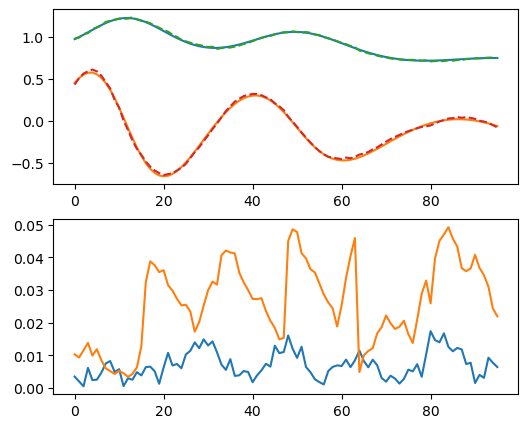

In [15]:
jdata = 5

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

## Evaluate KIND blending

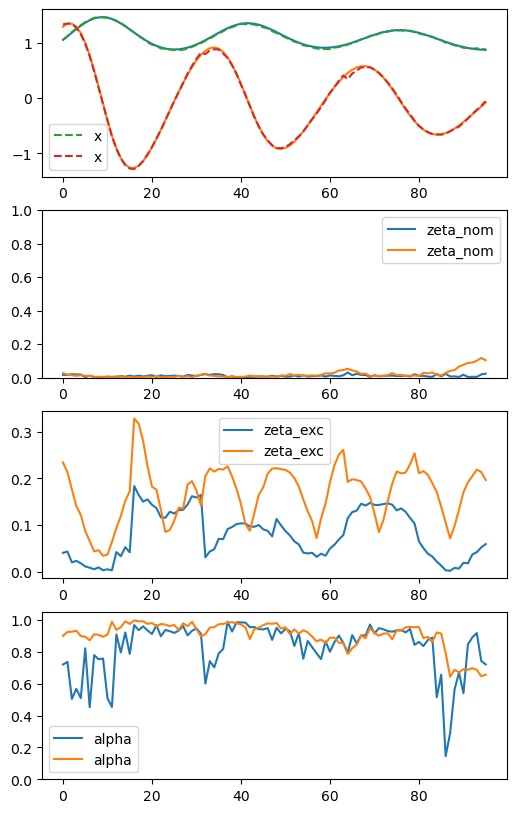

In [16]:
jdata = 4

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break